# Map cell identities between two experiments of the same sample, imaged on different microscopes

For a sample imaged twice on two different microscopes (e.g. `epi`
epifluorescence vs `disk` spinning-disk confocal — the same physical tissue,
re-mounted between sessions), finds a 1:1 cell-identity correspondence
between the two experiments' MERlin cell segmentations.

**Stage A** (coarse, tissue-level): fits a full similarity transform
(rotation + scale + translation + optional flips) between the two
experiments' tissue-boundary polygons
(`MERci.acquisition.alignment.fit_similarity_alignment`), bringing both
experiments' cells into one shared coordinate frame. No segmentation needed
— runs directly off the boundary files written during acquisition planning.

**Stage B** (fine, per-cell): mutual-nearest-neighbour matching on cell
centroids, refined by a cell-contact-graph consistency filter
(`MERci.analysis.cell_mapping`). Needs both experiments' MERlin run to have
reached `ExportCellMetadata`/`CombineCleanedBoundaries` — this section
checks for that output and reports clearly if it isn't there yet rather than
failing.

**Stage C** (using the mapping to clean up the lower-quality segmentation)
is **not implemented in this notebook yet** — see the closing section for
why and what the options are.

Both new functions were validated separately before being wired in here:
`fit_similarity_alignment` against a known synthetic transform *and* the
real `epi`/`disk` tissue boundaries in
`notebooks/tests/test_cross_microscope_similarity_alignment.ipynb`;
`match_mutual_nearest_neighbor`/`graph_consistency_filter` against a
synthetic cell population with a known ground-truth correspondence in
`notebooks/tests/test_cell_mapping_synthetic.ipynb` (real two-experiment
cell data does not exist yet to validate Stage B's real-data path against —
this notebook's own Stage B run is the first time it will see real data).

In [ ]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MERCI_DIR = Path(os.getcwd()).parent.parent   # MERci/ (notebook lives in MERci/notebooks/after_imaging/)
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.acquisition.alignment import load_boundary_polygon, fit_similarity_alignment, AlignmentResult
from MERci.visualization import get_merci_figures_dir
from MERci.analysis.cell_mapping import (
    build_contact_graph, match_mutual_nearest_neighbor, graph_consistency_filter,
)

NOTEBOOK_NAME = "06_map_cells_across_microscopes"

PLOT_TITLE_FONTSIZE    = 14
PLOT_LABEL_FONTSIZE    = 12
PLOT_TICK_FONTSIZE     = 11
PLOT_LEGEND_FONTSIZE   = 10
PLOT_SUPTITLE_FONTSIZE = 15

## 1 — Select the two experiments

Two separate experiment folders, not one shared `SAMPLE_DIR` with per-scope subfolders (unlike `misc/align_fovs_across_microscopes.ipynb`'s assumed layout) — both are explicit rather than auto-detected. `disk` is treated as *source* (higher z-resolution, confocal — the direction Stage C would need for mask cleanup) and `epi` as *target*; swap the labels below to run the other direction.

In [2]:
EPI_DIR  = Path("/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi")
DISK_DIR = Path("/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk")

SOURCE_DIR, SOURCE_LABEL = DISK_DIR, "disk"
TARGET_DIR, TARGET_LABEL = EPI_DIR,  "epi"

cache_dir   = SOURCE_DIR / "analysis" / "cache" / NOTEBOOK_NAME
figures_dir = get_merci_figures_dir(SOURCE_DIR, "after_imaging", NOTEBOOK_NAME)
cache_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"source ({SOURCE_LABEL}): {SOURCE_DIR}")
print(f"target ({TARGET_LABEL}): {TARGET_DIR}")


source (disk): /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk
target (epi): /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi


## 2 — Stage A: coarse tissue-boundary alignment

Fits the outer boundary ring only — `epi`'s boundary has holes (`hole1.txt`, `hole2.txt`) that are not subtracted here; revisit if the fitted IoU below is surprisingly low for a real re-mount of the same tissue (see the plan doc).

In [3]:
SOURCE_BOUNDARY = SOURCE_DIR / "positions" / "boundaries" / "from_mosaic" / "boundary_positions.txt"
TARGET_BOUNDARY = TARGET_DIR / "positions" / "boundaries" / "from_mosaic" / "boundary_positions.txt"

for p in (SOURCE_BOUNDARY, TARGET_BOUNDARY):
    print(f"{'OK ' if p.exists() else 'MISSING'}  {p}")

N_ANGLES   = 72
ALLOW_FLIP = True

boundary_fit_path = cache_dir / "boundary_fit.json"
cache_key = {
    "source_boundary_mtime": SOURCE_BOUNDARY.stat().st_mtime,
    "target_boundary_mtime": TARGET_BOUNDARY.stat().st_mtime,
    "n_angles": N_ANGLES, "allow_flip": ALLOW_FLIP,
}

cached = None
if boundary_fit_path.exists():
    with open(boundary_fit_path) as fh:
        cached = json.load(fh)
    if cached.get("cache_key") != cache_key:
        cached = None

if cached is not None:
    print(f"\nLoaded cached boundary fit: {boundary_fit_path}")
    fit_dict = cached["fit"]
else:
    source_poly = load_boundary_polygon(SOURCE_BOUNDARY)
    target_poly = load_boundary_polygon(TARGET_BOUNDARY)
    boundary_fit = fit_similarity_alignment(source_poly, target_poly, n_angles=N_ANGLES, allow_flip=ALLOW_FLIP)
    fit_dict = {
        "scale": boundary_fit.scale, "tx": boundary_fit.tx, "ty": boundary_fit.ty,
        "rotation_deg": boundary_fit.rotation_deg,
        "flip_x": boundary_fit.flip_x, "flip_y": boundary_fit.flip_y,
        "iou": boundary_fit.iou, "iou_init": boundary_fit.iou_init, "refined": boundary_fit.refined,
    }
    with open(boundary_fit_path, "w") as fh:
        json.dump({"cache_key": cache_key, "fit": fit_dict}, fh, indent=2)
    print(f"\nSaved boundary fit: {boundary_fit_path}")

boundary_fit = AlignmentResult(
    scale=fit_dict["scale"], tx=fit_dict["tx"], ty=fit_dict["ty"],
    iou=fit_dict["iou"], iou_init=fit_dict["iou_init"], n_iter=0,
    refined=fit_dict["refined"], flip_x=fit_dict["flip_x"], flip_y=fit_dict["flip_y"],
    rotation_deg=fit_dict["rotation_deg"],
)

print()
for k, v in fit_dict.items():
    print(f"{k:12s}: {v}")


OK   /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/positions/boundaries/from_mosaic/boundary_positions.txt
OK   /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/positions/boundaries/from_mosaic/boundary_positions.txt



Saved boundary fit: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/cache/06_map_cells_across_microscopes/boundary_fit.json

scale       : 0.9999357200567947
tx          : 2207.382222004134
ty          : -1324.4721417012072
rotation_deg: 356.74874233352347
flip_x      : True
flip_y      : True
iou         : 0.9339946689675941
iou_init    : 0.8884346186965119
refined     : True


Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/analysis/figures/06_map_cells_across_microscopes.disk_to_epi_boundary_fit.png


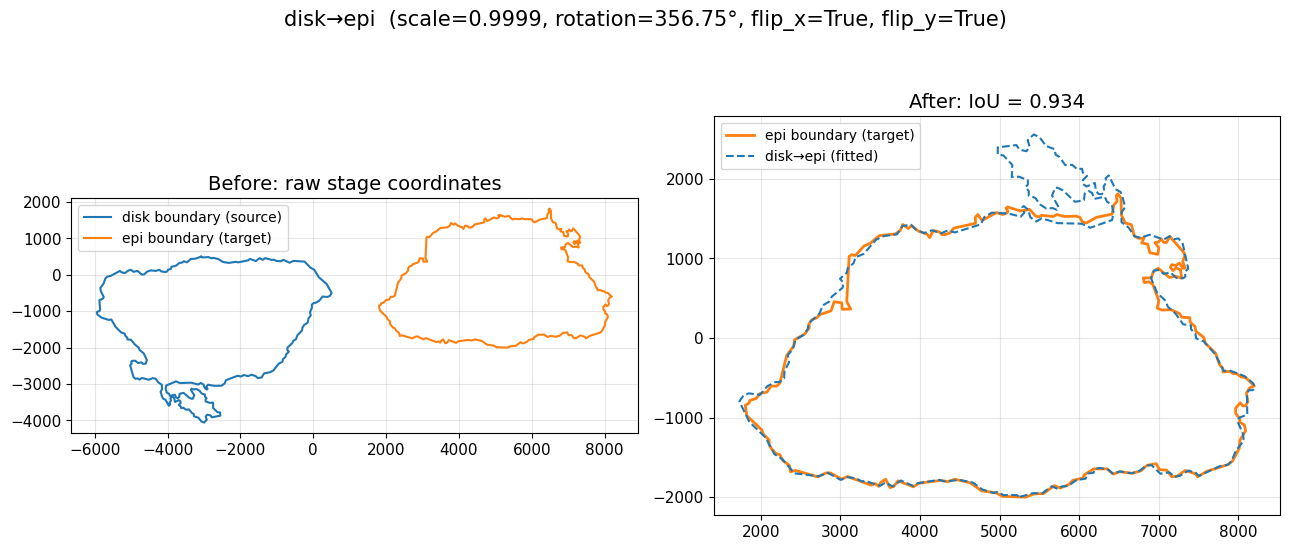

In [4]:
source_poly = load_boundary_polygon(SOURCE_BOUNDARY)
target_poly = load_boundary_polygon(TARGET_BOUNDARY)
mapped_poly = boundary_fit.transform_polygon(source_poly)


def _ring(poly):
    return np.asarray(poly.exterior.coords)


fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 6))

ax0.plot(*_ring(source_poly).T, "-", color="tab:blue",   label=f"{SOURCE_LABEL} boundary (source)")
ax0.plot(*_ring(target_poly).T, "-", color="tab:orange", label=f"{TARGET_LABEL} boundary (target)")
ax0.set_title("Before: raw stage coordinates", fontsize=PLOT_TITLE_FONTSIZE)
ax0.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax0.legend(fontsize=PLOT_LEGEND_FONTSIZE, loc="best")
ax0.set_aspect("equal"); ax0.grid(alpha=0.3)

ax1.plot(*_ring(target_poly).T, "-",  color="tab:orange", lw=2, label=f"{TARGET_LABEL} boundary (target)")
ax1.plot(*_ring(mapped_poly).T, "--", color="tab:blue",         label=f"{SOURCE_LABEL}→{TARGET_LABEL} (fitted)")
ax1.set_title(f"After: IoU = {boundary_fit.iou:.3f}", fontsize=PLOT_TITLE_FONTSIZE)
ax1.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax1.legend(fontsize=PLOT_LEGEND_FONTSIZE, loc="best")
ax1.set_aspect("equal"); ax1.grid(alpha=0.3)

fig.suptitle(
    f"{SOURCE_LABEL}→{TARGET_LABEL}  (scale={boundary_fit.scale:.4f}, "
    f"rotation={boundary_fit.rotation_deg:.2f}°, flip_x={boundary_fit.flip_x}, flip_y={boundary_fit.flip_y})",
    fontsize=PLOT_SUPTITLE_FONTSIZE,
)
fig.tight_layout()

fig_path = figures_dir / f"{NOTEBOOK_NAME}.{SOURCE_LABEL}_to_{TARGET_LABEL}_boundary_fit.png"
fig.savefig(fig_path, dpi=150)
print(f"Saved: {fig_path}")
plt.show()

if boundary_fit.iou < 0.8:
    print("\n⚠  Low IoU -- check that the boundaries are from the same sample, "
          "whether epi's holes need subtracting first, and that both boundary files are valid.")


## 3 — Stage B: per-cell matching

Needs both experiments' MERlin run to have reached `ExportCellMetadata` (`feature_metadata.csv`: `fov`, `volume`, `center_x`/`center_y` in global microns per cell). If either is missing, this section reports that clearly and the notebook stops here rather than failing.

In [5]:
SOURCE_CELLS_CSV = SOURCE_DIR / "merlin" / "output" / "ExportCellMetadata" / "feature_metadata.csv"
TARGET_CELLS_CSV = TARGET_DIR / "merlin" / "output" / "ExportCellMetadata" / "feature_metadata.csv"

SEGMENTATION_READY = SOURCE_CELLS_CSV.exists() and TARGET_CELLS_CSV.exists()

for label, p in ((SOURCE_LABEL, SOURCE_CELLS_CSV), (TARGET_LABEL, TARGET_CELLS_CSV)):
    print(f"{'OK ' if p.exists() else 'NOT YET'}  {label}: {p}")

if not SEGMENTATION_READY:
    print("\nSegmentation not finished for at least one experiment yet -- "
          "re-run this notebook once both MERlin runs reach ExportCellMetadata. "
          "Stopping here; Stage A's result above is still valid and cached.")


NOT YET  disk: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/disk/merlin/output/ExportCellMetadata/feature_metadata.csv
NOT YET  epi: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/merlin/output/ExportCellMetadata/feature_metadata.csv

Segmentation not finished for at least one experiment yet -- re-run this notebook once both MERlin runs reach ExportCellMetadata. Stopping here; Stage A's result above is still valid and cached.


In [6]:
if SEGMENTATION_READY:
    source_cells = pd.read_csv(SOURCE_CELLS_CSV, index_col=0)
    target_cells = pd.read_csv(TARGET_CELLS_CSV, index_col=0)
    print(f"{SOURCE_LABEL}: {len(source_cells)} cells")
    print(f"{TARGET_LABEL}: {len(target_cells)} cells")

    source_xy = source_cells[["center_x", "center_y"]].to_numpy()
    target_xy = target_cells[["center_x", "center_y"]].to_numpy()
    source_in_target_frame = boundary_fit.transform_points(source_xy)

    # Starting points only -- tune against this sample's *actual* residual
    # registration error / cell spacing once seen (see the plan doc's open
    # questions; these cannot be picked correctly in the abstract).
    MAX_DIST_UM     = 15.0   # ~ one cell radius
    CONTACT_DIST_UM = 30.0   # ~ one cell-to-cell spacing

    pairs, distances = match_mutual_nearest_neighbor(source_in_target_frame, target_xy, max_dist=MAX_DIST_UM)
    print(f"\nmutual nearest-neighbour matches: {len(pairs)} "
          f"({len(pairs) / min(len(source_cells), len(target_cells)):.1%} of the smaller population)")
    print(f"match distance (um): mean={distances.mean():.2f}  "
          f"median={np.median(distances):.2f}  max={distances.max():.2f}")

    source_adjacency = build_contact_graph(source_in_target_frame, CONTACT_DIST_UM)
    target_adjacency = build_contact_graph(target_xy, CONTACT_DIST_UM)
    filtered_pairs = graph_consistency_filter(pairs, source_adjacency, target_adjacency, min_fraction=0.5)
    print(f"after graph-consistency filter: {len(filtered_pairs)} "
          f"({len(pairs) - len(filtered_pairs)} removed)")

    match_df = pd.DataFrame(
        [(source_cells.index[i], target_cells.index[j], d)
         for (i, j), d in zip(pairs, distances)],
        columns=[f"{SOURCE_LABEL}_cell_id", f"{TARGET_LABEL}_cell_id", "distance_um"],
    )
    match_df["graph_consistent"] = [
        (i, j) in set(filtered_pairs) for i, j in pairs
    ]
    match_csv_path = cache_dir / "cell_matches.csv"
    match_df.to_csv(match_csv_path, index=False)
    print(f"\nSaved: {match_csv_path}")


## 4 — Stage C: cleaning up `epi`'s segmentation using `disk`'s — not implemented yet

Three options are laid out in the plan doc, cheapest/most-conservative first: (1) flag-only merge/split diagnostic (no mask changes), (2) direct mask overlay/replacement for confident 1:1 matches, (3) prior-informed re-segmentation (e.g. Baysor/RNA2seg-style). Building any of these now would mean writing mask-editing code with no real matched-cell data to check it against, and no confirmed choice yet of which option to build -- both need Stage B actually run against real `epi`/`disk` cells first. Once that's done, Section 3's `match_df` (cached above) is the input this stage will need.